# Sprint 1 – Cross-Referencing Pop-up Bike Lanes with Treatment Streets

**Project:** Urban Streetscape Intervention Analysis (USIA)  
**Team:** Team B — Traffic Volumes & Parking  
**Prepared by:** Pahalavan Kandeepan  
**Sprint:** Sprint 1  
**Research question:** How does parking use change after bike lanes are constructed?

---

### Objective

This notebook cross-references the Pop-up Bike Lanes dataset (Transport Victoria Open Data) against Team B's 96 treatment streets from the street_spatial dataset provided by Infrastructure Victoria. The goal is to find out which treatment streets have confirmed construction dates from the pop-up program and which ones don't.

## 1. Setup

In [3]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
print('Libraries loaded')

Libraries loaded


## 2. Load Both Datasets

In [4]:
# Load the IV treatment/control dataset
streets = gpd.read_file('streets_spatial.gpkg')
print(f'streets_spatial: {len(streets)} total segments')

# Load the popup bike lanes dataset
popup = gpd.read_file('popup_bike_lanes.geojson')
print(f'popup_bike_lanes: {len(popup)} segments')

# Filter to treatment streets only
treatment = streets[streets['treatment_or_control'] == 'treatment'].copy()
print(f'Treatment streets: {len(treatment)}')

streets_spatial: 315 total segments
popup_bike_lanes: 354 segments
Treatment streets: 96


## 3. Name-Based Matching

Match treatment streets to pop-up bike lanes by road name. Names are cleaned (uppercased, trimmed) before matching to handle formatting differences between the two datasets.

In [5]:
# clean street names for matching
treatment['name_clean'] = treatment['street_name'].str.upper().str.strip()
popup['name_clean'] = popup['roadnm'].str.upper().str.strip()

# unique names in each dataset
treatment_names = set(treatment['name_clean'].unique())
popup_names = set(popup['name_clean'].unique())

# find matches
matched_names = treatment_names & popup_names
unmatched_names = treatment_names - popup_names

print(f'Unique treatment street names: {len(treatment_names)}')
print(f'Unique pop-up bike lane road names: {len(popup_names)}')
print(f'Matched names: {len(matched_names)}')
print(f'Unmatched names: {len(unmatched_names)}')

Unique treatment street names: 41
Unique pop-up bike lane road names: 109
Matched names: 7
Unmatched names: 34


## 4. Matched Streets — With Construction Dates

In [6]:
print('=== MATCHED STREETS (have construction dates from pop-up program) ===\n')

matched_data = []
for name in sorted(matched_names):
    t_rows = treatment[treatment['name_clean'] == name]
    p_rows = popup[popup['name_clean'] == name]

    suburbs = ', '.join(t_rows['suburb'].unique())
    lgas = ', '.join(t_rows['lga'].unique())
    dates = ', '.join(p_rows['trialdate'].dropna().unique())
    itype = ', '.join(t_rows['intervention_type'].unique())
    segments = len(t_rows)

    matched_data.append({
        'Street': name.title(),
        'Suburb': suburbs,
        'LGA': lgas,
        'Intervention': itype,
        'Trial Date': dates,
        'Segments': segments
    })

matched_df = pd.DataFrame(matched_data)
display(matched_df)

=== MATCHED STREETS (have construction dates from pop-up program) ===



,Street,Suburb,LGA,Intervention,Trial Date,Segments
0,Acland Street,St Kilda,Port Phillip (C),pedestrian,Jul-22,1
1,Albert Street,East Melbourne,Melbourne (C),protected bike lane,Jul-22,5
2,Heidelberg Road,"Clifton Hill, Fairfield","Yarra (C), Darebin (C)",protected bike lane,Apr-21,4
3,Park Street,Melbourne,Melbourne (C),protected bike lane,Jul-22,1
4,Walker Street,Dandenong,Greater Dandenong (C),protected bike lane,Feb-22,2
5,Wellington Street,Collingwood,Yarra (C),protected bike lane,Feb-22,3
6,William Street,Melbourne,Melbourne (C),protected bike lane,Jul-22,4


## 5. Unmatched Streets — No Construction Dates

In [7]:
print('=== UNMATCHED STREETS (no pop-up bike lane data available) ===\n')

unmatched_data = []
for name in sorted(unmatched_names):
    t_rows = treatment[treatment['name_clean'] == name]
    suburbs = ', '.join(t_rows['suburb'].unique())
    lgas = ', '.join(t_rows['lga'].unique())
    itype = ', '.join(t_rows['intervention_type'].unique())
    segments = len(t_rows)

    unmatched_data.append({
        'Street': name.title(),
        'Suburb': suburbs,
        'LGA': lgas,
        'Intervention': itype,
        'Segments': segments
    })

unmatched_df = pd.DataFrame(unmatched_data)
display(unmatched_df)

=== UNMATCHED STREETS (no pop-up bike lane data available) ===



,Street,Suburb,LGA,Intervention,Segments
0,Abbotsford Street,"North Melbourne, West Melbourne",Melbourne (C),protected bike lane,5
1,Acland,St Kilda,Port Phillip (C),pedestrian,1
2,Anzac Avenue,Melbourne,Melbourne (C),protected bike lane,1
3,Armstrong St,Ballarat Central,Ballarat (C),regional_reallocation,1
4,Bair St,Leongatha,South Gippsland (S),regional_reallocation,1
5,Ballarat St,Yarraville,Maribyrnong (C),pedestrian,1
6,Ballarat St (Sth),Yarraville,Maribyrnong (C),pedestrian,1
7,Cecil Street,South Melbourne,Port Phillip (C),protected bike lane,2
8,City Road,Southbank,Melbourne (C),protected bike lane,1
9,Dawson Street,Brunswick,Merri-Bek (C),protected bike lane,1


## 6. Segment-Level Summary

In [8]:
matched_segments = treatment[treatment['name_clean'].isin(matched_names)]
unmatched_segments = treatment[~treatment['name_clean'].isin(matched_names)]

print('=== SEGMENT-LEVEL SUMMARY ===')
print(f'Total treatment segments: {len(treatment)}')
print(f'Matched (have dates): {len(matched_segments)} segments ({len(matched_segments)/len(treatment)*100:.1f}%)')
print(f'Unmatched (no dates): {len(unmatched_segments)} segments ({len(unmatched_segments)/len(treatment)*100:.1f}%)')
print()

print('Unmatched by intervention type:')
print(unmatched_segments['intervention_type'].value_counts().to_string())
print()

print('Unmatched by location:')
print(f'  CBD: {int(unmatched_segments["cbd"].sum())}')
print(f'  Metro: {int(unmatched_segments["metro"].sum())}')
print(f'  Regional: {int(unmatched_segments["regional"].sum())}')

=== SEGMENT-LEVEL SUMMARY ===
Total treatment segments: 96
Matched (have dates): 20 segments (20.8%)
Unmatched (no dates): 76 segments (79.2%)

Unmatched by intervention type:
intervention_type
protected bike lane      61
regional_reallocation    10
pedestrian                5

Unmatched by location:
  CBD: 12
  Metro: 49
  Regional: 15


## 7. Visualisation — Match Coverage

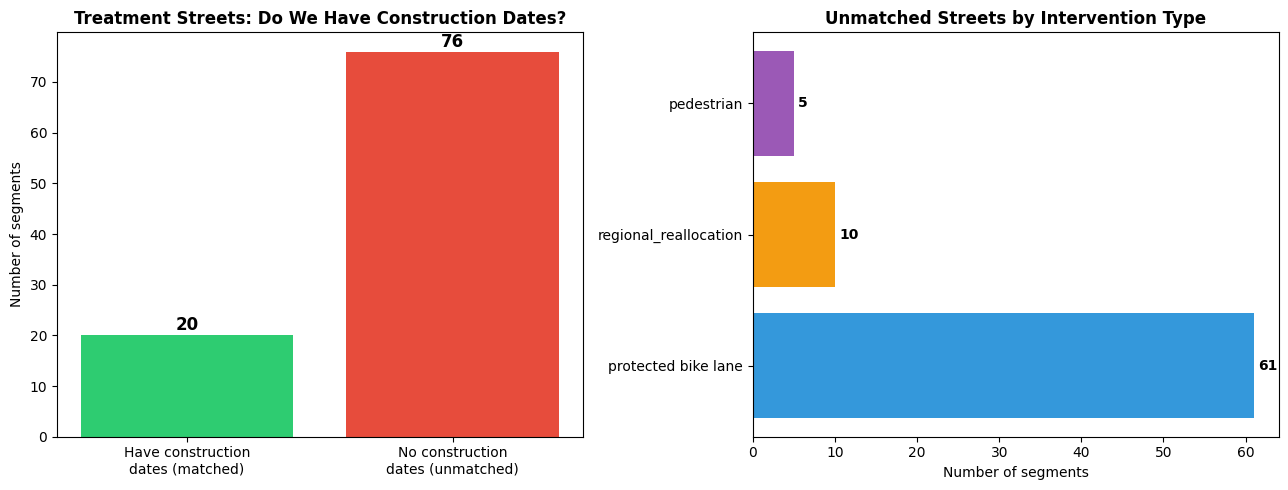

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1: matched vs unmatched segments
labels = ['Have construction\ndates (matched)', 'No construction\ndates (unmatched)']
counts = [len(matched_segments), len(unmatched_segments)]
colours = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(labels, counts, color=colours)
axes[0].set_title('Treatment Streets: Do We Have Construction Dates?', fontweight='bold')
axes[0].set_ylabel('Number of segments')
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(count), ha='center', fontweight='bold', fontsize=12)

# Chart 2: unmatched by intervention type
um_types = unmatched_segments['intervention_type'].value_counts()
type_colours = ['#3498db', '#f39c12', '#9b59b6']
bars2 = axes[1].barh(um_types.index, um_types.values, color=type_colours[:len(um_types)])
axes[1].set_title('Unmatched Streets by Intervention Type', fontweight='bold')
axes[1].set_xlabel('Number of segments')
for bar, count in zip(bars2, um_types.values):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 str(count), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('match_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Map — Matched vs Unmatched Treatment Streets

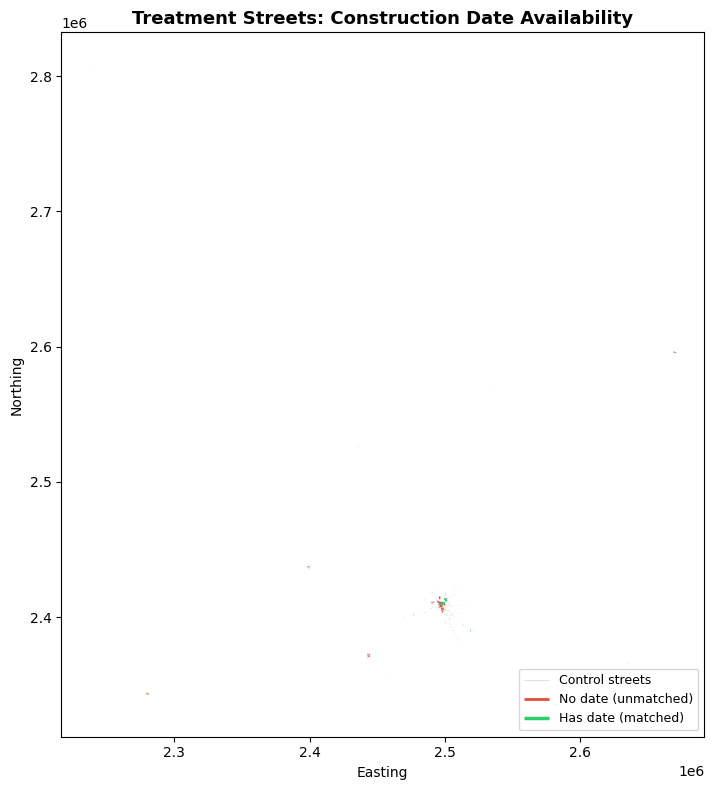

Map saved


In [10]:
# add match status to treatment streets
treatment['match_status'] = treatment['name_clean'].apply(
    lambda x: 'Matched' if x in matched_names else 'Unmatched'
)

# plot control streets as background
control = streets[streets['treatment_or_control'] == 'control']

fig, ax = plt.subplots(figsize=(12, 8))
control.plot(ax=ax, color='#d5d5d5', linewidth=0.5, label='Control streets')

matched_gdf = treatment[treatment['match_status'] == 'Matched']
unmatched_gdf = treatment[treatment['match_status'] == 'Unmatched']

unmatched_gdf.plot(ax=ax, color='#e74c3c', linewidth=2, label='No date (unmatched)')
matched_gdf.plot(ax=ax, color='#2ecc71', linewidth=2.5, label='Has date (matched)')

ax.set_title('Treatment Streets: Construction Date Availability', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlabel('Easting')
ax.set_ylabel('Northing')

plt.tight_layout()
plt.savefig('matched_vs_unmatched_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Map saved')

## 9. Key Findings

- Out of 41 unique treatment street names, only **7 matched** with the Pop-up Bike Lanes dataset.
- At segment level, **20 out of 96 treatment segments (20.8%)** have confirmed construction dates from the pop-up program.
- The remaining **76 segments (79.2%)** do not appear in the Pop-up Bike Lanes dataset and will need construction dates from other sources.
- Of the 76 unmatched segments, 61 are protected bike lanes — meaning most of the PO's highest priority intervention type does not have dates in this dataset.
- The matched streets are: Acland Street (St Kilda), Albert Street (East Melbourne), Heidelberg Road (Clifton Hill/Fairfield), Park Street (Melbourne), Walker Street (Dandenong), Wellington Street (Collingwood), and William Street (Melbourne).
- Most unmatched streets are in the City of Melbourne LGA (major streets like Swanston St, Exhibition St, La Trobe St, St Kilda Rd) — these are likely older protected bike lanes that predate the pop-up program.
- All regional treatment streets (Ballarat, Warrnambool, Wodonga, Geelong, Leongatha) are unmatched since the pop-up program only covered metropolitan Melbourne.

## 10. What This Means for the Team

- The Pop-up Bike Lanes dataset only covers a small portion of our treatment streets. For the majority of sites, construction dates will need to come from either Infrastructure Victoria directly or from other public sources like council records.
- The 7 matched streets with confirmed trial dates can serve as pilot sites for the parking analysis — we can start the before/after comparison on these while waiting for dates on the rest.
- The team should flag this gap with the PO and ask whether they can provide a complete list of construction dates for all 96 treatment streets.